In [1]:
import logging
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cross_decomposition import PLSRegression

In [2]:
BASE_DATA_DIR = Path().resolve().parent 
BASE_MODELS = BASE_DATA_DIR  / "data" / "modelos"


In [3]:
# 1. Carregamento dos splits
caminho_prep = BASE_MODELS  / 'preprocess.pkl'
caminho_splits = BASE_MODELS  / 'data_splits.pkl'
    

preprocess = joblib.load(caminho_prep)
X_train, X_test, y_train, y_test = joblib.load(caminho_splits)

In [5]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 325597 entries, 242163 to 13438
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   uf                      325597 non-null  str    
 1   br                      324800 non-null  str    
 2   km                      324800 non-null  str    
 3   dia_semana              325597 non-null  str    
 4   fase_dia                325597 non-null  str    
 5   sentido_via             325597 non-null  str    
 6   condicao_metereologica  325597 non-null  str    
 7   tipo_pista              325597 non-null  str    
 8   uso_solo                325597 non-null  str    
 9   tipo_veiculo            313924 non-null  str    
 10  ano                     325597 non-null  str    
 11  frota                   322478 non-null  float64
 12  br_km                   324800 non-null  str    
 13  Aclive                  325597 non-null  int64  
 14  Curva                   325597 n

In [4]:

# 2. Transformar os dados usando o pipeline original
# (A coluna 'km' ainda está no X_train aqui para o pipeline não dar erro de validação)
X_train_transformed = preprocess.transform(X_train)
y_train = y_train.values.ravel()

# Transformar dados esparsos em densos
X_train_denso = X_train_transformed.astype('float32').toarray()
nomes_ohe = preprocess.get_feature_names_out()

# 👉 3. DESCARTAR AS COLUNAS DA 'km' ANTES DE TREINAR O PLS
# Filtramos os nomes: removemos tudo que começa com 'cat__km_'. 
# Note que 'cat__br_km_' NÃO entra nessa regra e será mantido perfeitamente!
indices_manter = [i for i, nome in enumerate(nomes_ohe) if not nome.startswith('cat__km_')]

X_train_filtrado = X_train_denso[:, indices_manter]
nomes_ohe_filtrados = nomes_ohe[indices_manter]

# 4. Treinar o modelo PLS apenas com os dados filtrados (Sem nenhum resquício da KM)
pls = PLSRegression(n_components=2)
pls.fit(X_train_filtrado, y_train)

# 5. Extrair os nomes das colunas mantidas e os pesos calculados
pesos_pls = pls.x_loadings_[:, 0]

# 6. Criar o DataFrame com os pesos individuais
df_pesos = pd.DataFrame({
    'Coluna_Gerada': nomes_ohe_filtrados,
    'Peso_PLS': pesos_pls,
    'Peso_Absoluto': np.abs(pesos_pls)
})

# 7. Lógica para mapear a coluna gerada de volta para a variável original
colunas_originais = X_train.columns.tolist()

# Como descartamos a 'km' do modelo, removemos ela da lista de mapeamento também
if 'km' in colunas_originais:
    colunas_originais.remove('km')

# Ordenar as colunas por tamanho (decrescente) para garantir que 'br_km' seja avaliado antes de 'br'
colunas_originais_ordenadas = sorted(colunas_originais, key=len, reverse=True)

colunas_tracado_via = [
    'Aclive', 'Curva', 'Declive', 'Desvio Temporário', 'Em Obras', 
    'Interseção de Vias', 'Ponte', 'Reta', 'Retorno Regulamentado', 
    'Rotatória', 'Túnel', 'Viaduto'
]

def mapear_para_original(coluna_ohe, colunas_ordenadas, lista_tracado):
    for tracado in lista_tracado:
        if tracado in coluna_ohe:
            return "tracado_via"
            
    for col_orig in colunas_ordenadas:
        if col_orig in coluna_ohe:
            return col_orig
            
    return coluna_ohe 

# Aplicar o mapeamento
df_pesos['Variavel_Original'] = df_pesos['Coluna_Gerada'].apply(
    lambda x: mapear_para_original(x, colunas_originais_ordenadas, colunas_tracado_via)
)

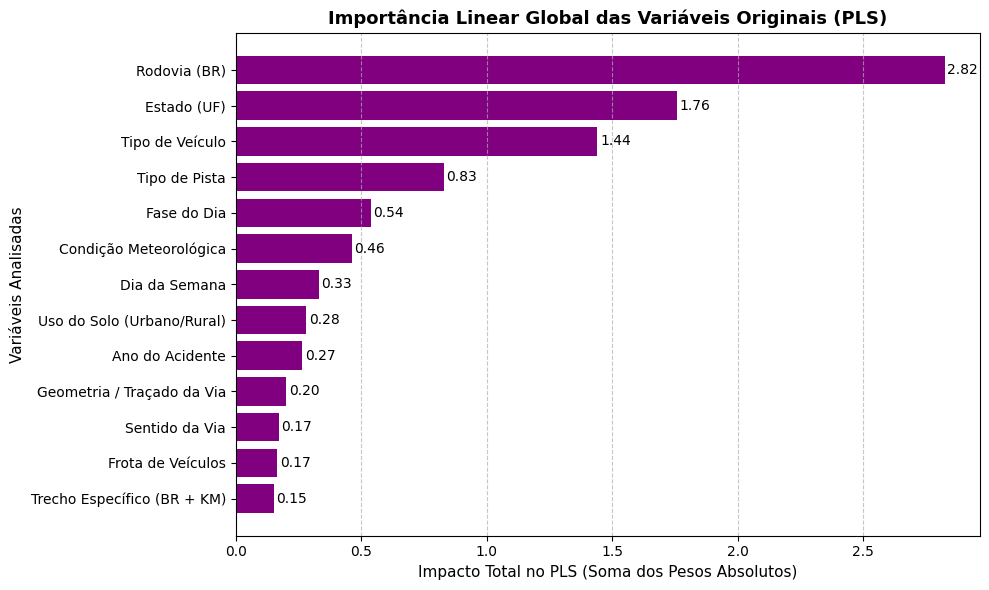

In [ ]:
# 8. Agrupar pela variável original E ALTERAR OS NOMES PARA EXIBIÇÃO
df_agrupado = df_pesos.groupby('Variavel_Original')['Peso_Absoluto'].sum().reset_index()

# ⚠️ DICIONÁRIO DE TRADUÇÃO: Mude o texto da direita para o nome que você quiser!
nomes_customizados = {
    'br': 'Rodovia (BR)',
    'br_km': 'Trecho Específico (BR + KM)',
    'uf': 'Estado (UF)',
    'dia_semana': 'Dia da Semana',
    'fase_dia': 'Fase do Dia',
    'sentido_via': 'Sentido da Via',
    'condicao_metereologica': 'Condição Meteorológica',
    'tipo_pista': 'Tipo de Pista',
    'uso_solo': 'Uso do Solo (Urbano/Rural)',
    'tipo_veiculo': 'Tipo de Veículo',
    'ano': 'Ano do Acidente',
    'frota': 'Frota de Veículos',
    'tracado_via': 'Geometria / Traçado da Via'
}

# Aplica a tradução (se o nome não estiver no dicionário, ele mantém o original)
df_agrupado['Variavel_Original'] = df_agrupado['Variavel_Original'].map(nomes_customizados).fillna(df_agrupado['Variavel_Original'])

# Ordenar novamente após a renomeação para garantir a ordem correta no gráfico
df_agrupado = df_agrupado.sort_values(by='Peso_Absoluto', ascending=False)


# 9. Plotar o Gráfico com os novos nomes
plt.figure(figsize=(10, 6))

variaveis = df_agrupado['Variavel_Original'][::-1]
valores = df_agrupado['Peso_Absoluto'][::-1]

plt.barh(variaveis, valores, color='purple')

# Adicionar os valores no final das barras
for i, v in enumerate(valores):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)

plt.xlabel('Impacto Total no PLS (Soma dos Pesos Absolutos)', fontsize=11)
plt.ylabel('Variáveis Analisadas', fontsize=11)
plt.title('Importância Linear Global das Variáveis Originais (PLS)', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()